In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

DATASET_SAVE_PATH = "give the path to the directory containing 2019, 2020, 2021, and 2022 week3  datasets here"

# ── Load all year datasets ─────────────────────────────────────────────
df_2019 = pd.read_parquet(DATASET_SAVE_PATH + "df_2019_features.parquet")
df_2020 = pd.read_parquet(DATASET_SAVE_PATH + "df_2020_features.parquet")
df_2021 = pd.read_parquet(DATASET_SAVE_PATH + "df_2021_features.parquet")
df_2022 = pd.read_parquet(DATASET_SAVE_PATH + "df_2022_features.parquet")

for df, yr in [(df_2019,2019),(df_2020,2020),(df_2021,2021),(df_2022,2022)]:
    df["year"] = yr

FEATURES = [
    "trip_distance", "is_airport_trip", "is_night",
    "do_zone_type_enc", "same_zone", "PULocationID", "DOLocationID",
    "pickup_hour", "is_rush_hour", "pickup_month",
    "pickup_dow", "is_weekend", "rate_type_enc", "pu_zone_type_enc",
]
TARGET = "trip_duration"

# Combine all years into one sorted timeline
df_all = pd.concat([df_2019, df_2020, df_2021, df_2022], ignore_index=True)
df_all["tpep_pickup_datetime"] = pd.to_datetime(df_all["tpep_pickup_datetime"])
df_all = df_all.sort_values("tpep_pickup_datetime").reset_index(drop=True)
df_all["period"] = df_all["year"].astype(str) + "-" + df_all["pickup_month"].apply(lambda m: f"{m:02d}")

print(f"Combined: {df_all.shape}")
print(df_all.groupby("period").size().to_string())

Combined: (1563589, 23)
period
2019-01    74435
2019-02    68039
2019-03    75840
2019-04    71919
2019-05    73083
2019-06    66932
2019-07    60296
2019-08        1
2019-09    62888
2019-10    69080
2019-11        4
2019-12    65865
2020-01    61061
2020-02    60200
2020-03    28472
2020-04     2057
2020-05     2676
2020-06     4657
2020-07     6876
2020-08     8757
2020-09    11895
2020-10    15096
2020-11    13505
2020-12    13094
2021-01    12145
2021-02    12182
2021-03    17163
2021-04    19527
2021-05    22771
2021-06    25887
2021-07    25697
2021-08    25277
2021-09    26741
2021-10    31752
2021-11    31975
2021-12    29810
2022-01    22835
2022-02    27561
2022-03    33628
2022-04    33355
2022-05    33025
2022-06    32687
2022-07    29325
2022-08    29176
2022-09    29225
2022-10    33793
2022-11    30064
2022-12    31260


 ── Helper: train and evaluate ─────────────────────────────────────────


In [3]:
# ── Helper: train and evaluate ─────────────────────────────────────────
def train_xgb(X_train, y_train):
    model = XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
    model.fit(X_train, y_train)
    return model

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100
    return round(mae,4), round(rmse,4), round(mape,4)

# All periods in order
all_periods = sorted(df_all["period"].unique())
print(f"Total periods: {len(all_periods)}")

Total periods: 48


── STRATEGY 1: No retraining (frozen 2019 model) ──────────────────────


In [4]:
# ── STRATEGY 1: No retraining (frozen 2019 model) ──────────────────────
# Already done in Phase 3b — load from saved results

drift_results = pd.read_parquet(SAVE_PATH + "drift_results_2020_2022.parquet")
baseline_results = pd.read_parquet(SAVE_PATH + "walk_forward_results_2019.parquet")
baseline_clean = baseline_results[baseline_results["test_size"] > 100].copy()
baseline_clean["period"] = baseline_clean["test_month"].apply(lambda m: f"2019-{m:02d}")

frozen = pd.concat([
    baseline_clean[["period","xgb_mae","xgb_rmse","xgb_mape"]],
    drift_results[["period","xgb_mae","xgb_rmse","xgb_mape"]]
], ignore_index=True).sort_values("period").reset_index(drop=True)

print("Strategy 1 (Frozen) loaded:")
print(f"  Periods: {len(frozen)}")
print(f"  Avg MAE: {frozen['xgb_mae'].mean():.4f}")
print(f"  Avg MAPE: {frozen['xgb_mape'].mean():.2f}%")

Strategy 1 (Frozen) loaded:
  Periods: 45
  Avg MAE: 3.6428
  Avg MAPE: 34.75%


── STRATEGY 2: Periodic retraining (every 6 months) ───────────────────


In [5]:
# ── STRATEGY 2: Periodic retraining (every 6 months) ───────────────────
# Retrain every 6 months regardless of performance
# Simulates calendar-based retraining used in production systems

results_periodic = []
model_periodic = train_xgb(df_2019[FEATURES], df_2019[TARGET])
retrain_log_periodic = ["2019 (initial)"]

post2019_periods = sorted([p for p in all_periods if p >= "2020-01"])

for i, period in enumerate(post2019_periods):
    subset = df_all[df_all["period"] == period]
    if len(subset) < 10:
        continue

    X_test = subset[FEATURES]
    y_test = subset[TARGET]
    mae, rmse, mape = evaluate(model_periodic, X_test, y_test)

    results_periodic.append({
        "period": period, "xgb_mae": mae,
        "xgb_rmse": rmse, "xgb_mape": mape,
        "retrained": False
    })

    # Retrain every 6 months using all data up to current period
    if (i + 1) % 6 == 0:
        train_data = df_all[df_all["period"] <= period]
        model_periodic = train_xgb(train_data[FEATURES], train_data[TARGET])
        retrain_log_periodic.append(period)
        results_periodic[-1]["retrained"] = True
        print(f"  Periodic retrain at: {period} | "
              f"Train size: {len(train_data):,} | MAE after: {mae:.4f}")

df_periodic = pd.DataFrame(results_periodic)
print(f"\nStrategy 2 (Periodic) complete:")
print(f"  Retrains performed: {len(retrain_log_periodic)-1}")
print(f"  Avg MAE: {df_periodic['xgb_mae'].mean():.4f}")
print(f"  Avg MAPE: {df_periodic['xgb_mape'].mean():.2f}%")

  Periodic retrain at: 2020-06 | Train size: 847,505 | MAE after: 4.8792
  Periodic retrain at: 2020-12 | Train size: 916,728 | MAE after: 2.9390
  Periodic retrain at: 2021-06 | Train size: 1,026,403 | MAE after: 3.0398
  Periodic retrain at: 2021-12 | Train size: 1,197,655 | MAE after: 3.4309
  Periodic retrain at: 2022-06 | Train size: 1,380,746 | MAE after: 3.3592
  Periodic retrain at: 2022-12 | Train size: 1,563,589 | MAE after: 3.9498

Strategy 2 (Periodic) complete:
  Retrains performed: 6
  Avg MAE: 3.2583
  Avg MAPE: 28.65%


 ── STRATEGY 3: Performance-triggered retraining ───────────────────────


In [6]:
# ── STRATEGY 3: Performance-triggered retraining ───────────────────────
# Retrain only when MAPE exceeds 1.5x baseline threshold
# Simulates intelligent drift-triggered retraining

TRIGGER_THRESHOLD = baseline_clean["xgb_mape"].mean() * 1.5  # 38.5%
print(f"Trigger threshold: {TRIGGER_THRESHOLD:.2f}% MAPE")

results_triggered = []
model_triggered = train_xgb(df_2019[FEATURES], df_2019[TARGET])
retrain_log_triggered = ["2019 (initial)"]
consecutive_violations = 0
VIOLATION_WINDOW = 2  # retrain after 2 consecutive months above threshold

for period in post2019_periods:
    subset = df_all[df_all["period"] == period]
    if len(subset) < 10:
        continue

    X_test = subset[FEATURES]
    y_test = subset[TARGET]
    mae, rmse, mape = evaluate(model_triggered, X_test, y_test)

    retrained = False
    if mape > TRIGGER_THRESHOLD:
        consecutive_violations += 1
    else:
        consecutive_violations = 0

    # Trigger retraining after consecutive violations
    if consecutive_violations >= VIOLATION_WINDOW:
        train_data = df_all[df_all["period"] <= period]
        model_triggered = train_xgb(train_data[FEATURES], train_data[TARGET])
        retrain_log_triggered.append(period)
        consecutive_violations = 0
        retrained = True
        # Re-evaluate after retraining
        mae, rmse, mape = evaluate(model_triggered, X_test, y_test)
        print(f"  Triggered retrain at: {period} | "
              f"Train size: {len(train_data):,} | MAE after: {mae:.4f} | MAPE after: {mape:.2f}%")

    results_triggered.append({
        "period": period, "xgb_mae": mae,
        "xgb_rmse": rmse, "xgb_mape": mape,
        "retrained": retrained
    })

df_triggered = pd.DataFrame(results_triggered)
print(f"\nStrategy 3 (Triggered) complete:")
print(f"  Retrains performed: {len(retrain_log_triggered)-1}")
print(f"  Avg MAE: {df_triggered['xgb_mae'].mean():.4f}")
print(f"  Avg MAPE: {df_triggered['xgb_mape'].mean():.2f}%")

Trigger threshold: 38.54% MAPE
  Triggered retrain at: 2020-05 | Train size: 842,848 | MAE after: 3.1005 | MAPE after: 36.73%

Strategy 3 (Triggered) complete:
  Retrains performed: 1
  Avg MAE: 3.3173
  Avg MAPE: 29.28%


── STRATEGY 4: Monthly retraining (upper bound) ───────────────────────


In [7]:
# ── STRATEGY 4: Monthly retraining (upper bound) ───────────────────────
# Retrain every single month — maximum possible accuracy
# This is the performance ceiling — most expensive strategy

results_monthly = []
model_monthly = train_xgb(df_2019[FEATURES], df_2019[TARGET])

for i, period in enumerate(post2019_periods):
    subset = df_all[df_all["period"] == period]
    if len(subset) < 10:
        continue

    X_test = subset[FEATURES]
    y_test = subset[TARGET]
    mae, rmse, mape = evaluate(model_monthly, X_test, y_test)

    results_monthly.append({
        "period": period, "xgb_mae": mae,
        "xgb_rmse": rmse, "xgb_mape": mape,
        "retrained": True
    })

    # Always retrain on all data up to current period
    train_data = df_all[df_all["period"] <= period]
    model_monthly = train_xgb(train_data[FEATURES], train_data[TARGET])

df_monthly = pd.DataFrame(results_monthly)
print(f"Strategy 4 (Monthly) complete:")
print(f"  Retrains performed: {len(post2019_periods)}")
print(f"  Avg MAE: {df_monthly['xgb_mae'].mean():.4f}")
print(f"  Avg MAPE: {df_monthly['xgb_mape'].mean():.2f}%")

Strategy 4 (Monthly) complete:
  Retrains performed: 36
  Avg MAE: 3.1569
  Avg MAPE: 27.63%


── SECTION 5: Strategy comparison summary ─────────────────────────────


In [8]:
# ── SECTION 5: Strategy comparison summary ─────────────────────────────

print("\n" + "="*65)
print("RETRAINING STRATEGY COMPARISON SUMMARY")
print("="*65)
print(f"{'Strategy':<35} {'Avg MAE':<12} {'Avg MAPE':<12} {'Retrains'}")
print("-"*65)

strategies = [
    ("1. No retraining (frozen)",
     drift_results["xgb_mae"].mean(),
     drift_results["xgb_mape"].mean(),
     0),
    ("2. Periodic (every 6 months)",
     df_periodic["xgb_mae"].mean(),
     df_periodic["xgb_mape"].mean(),
     len(retrain_log_periodic)-1),
    ("3. Performance-triggered",
     df_triggered["xgb_mae"].mean(),
     df_triggered["xgb_mape"].mean(),
     len(retrain_log_triggered)-1),
    ("4. Monthly (upper bound)",
     df_monthly["xgb_mae"].mean(),
     df_monthly["xgb_mape"].mean(),
     len(post2019_periods)),
]

for name, mae, mape, retrains in strategies:
    print(f"{name:<35} {mae:<12.4f} {mape:<12.2f}% {retrains}")

# Improvement over frozen
frozen_mape = drift_results["xgb_mape"].mean()
print(f"\nImprovement over frozen baseline ({frozen_mape:.2f}% MAPE):")
for name, mae, mape, retrains in strategies[1:]:
    improvement = ((frozen_mape - mape) / frozen_mape) * 100
    print(f"  {name}: {improvement:.1f}% reduction in MAPE")


RETRAINING STRATEGY COMPARISON SUMMARY
Strategy                            Avg MAE      Avg MAPE     Retrains
-----------------------------------------------------------------
1. No retraining (frozen)           3.7561       37.02       % 0
2. Periodic (every 6 months)        3.2583       28.65       % 6
3. Performance-triggered            3.3173       29.28       % 1
4. Monthly (upper bound)            3.1569       27.63       % 36

Improvement over frozen baseline (37.02% MAPE):
  2. Periodic (every 6 months): 22.6% reduction in MAPE
  3. Performance-triggered: 20.9% reduction in MAPE
  4. Monthly (upper bound): 25.4% reduction in MAPE


 ── SECTION 6: Visualisation ───────────────────────────────────────────


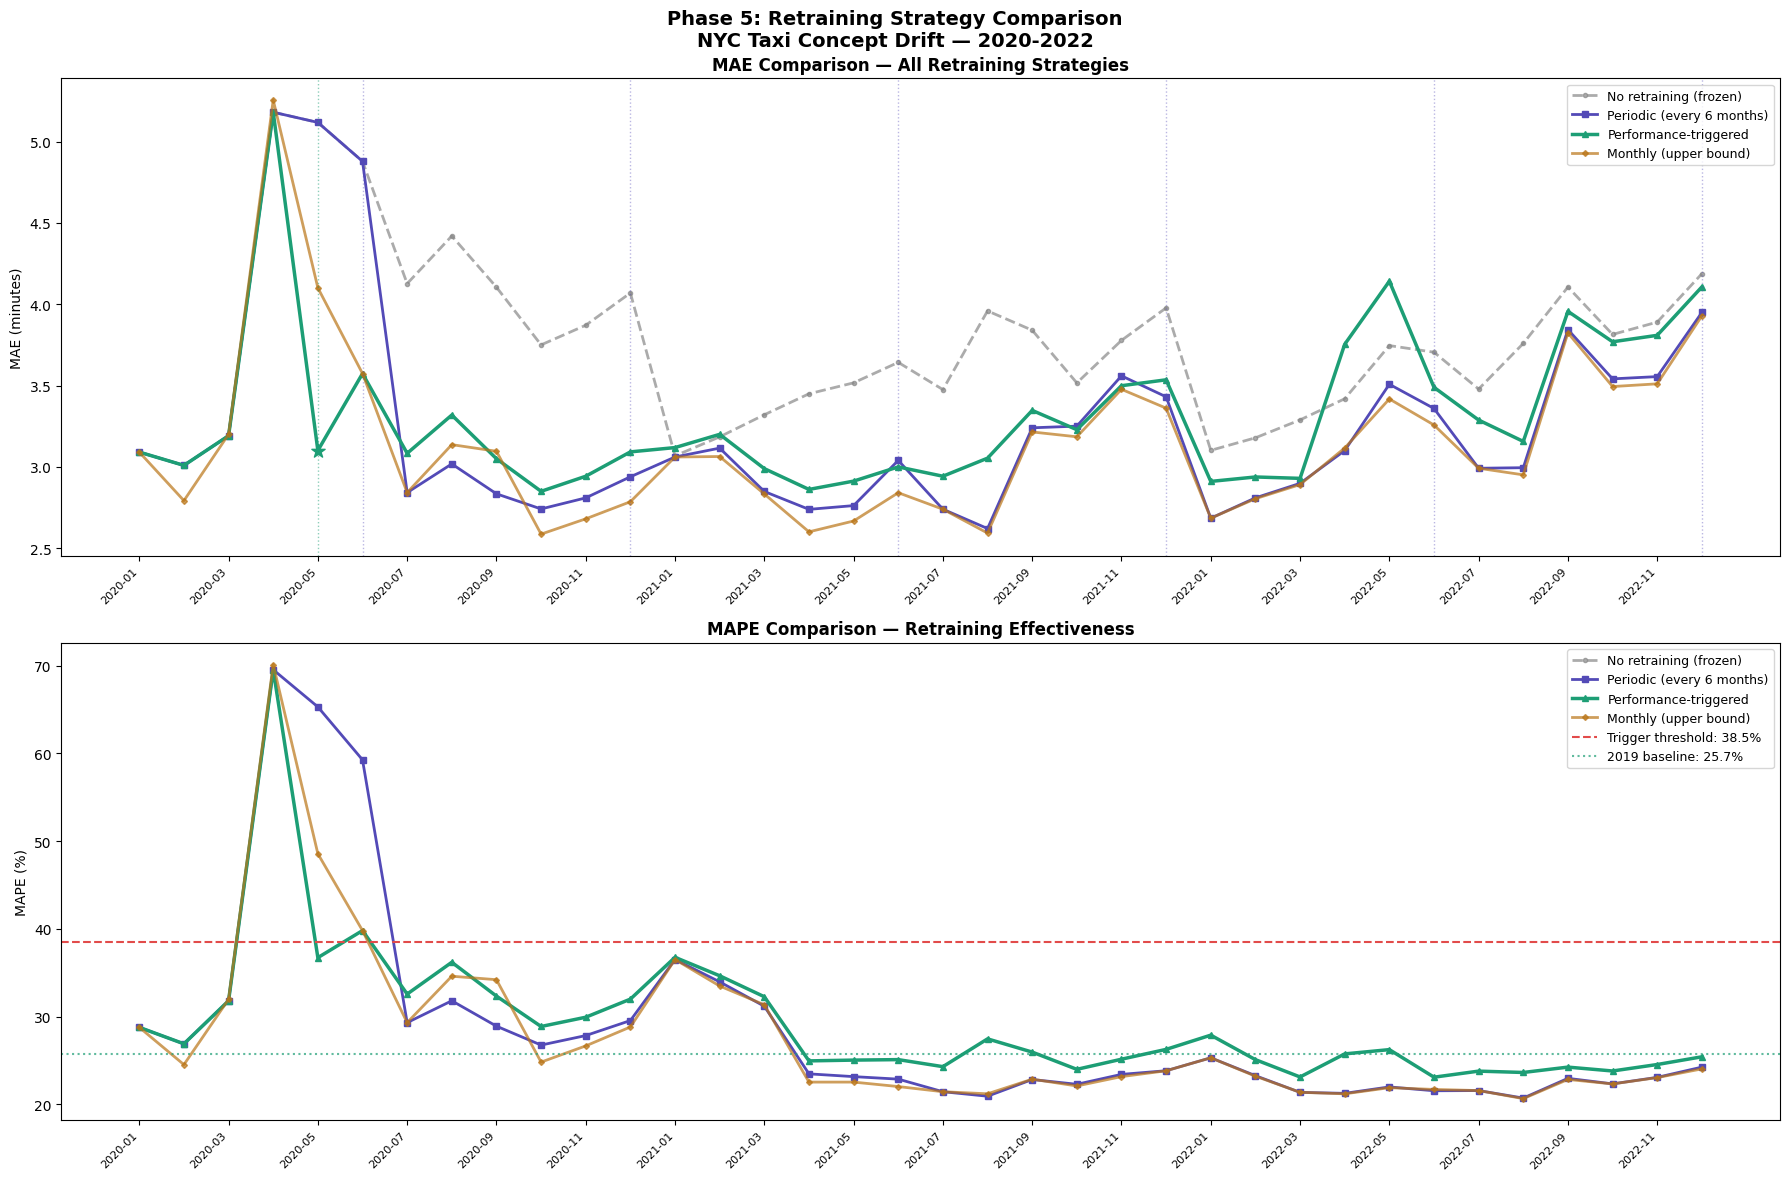

Saved: retraining_strategy_comparison.png


In [ ]:
# ── SECTION 6: Visualisation ───────────────────────────────────────────
SAVE_PATH="give the path to save models and results here"
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle("Phase 5: Retraining Strategy Comparison\nNYC Taxi Concept Drift — 2020-2022",
             fontsize=14, fontweight="bold")

periods_post = df_periodic["period"].tolist()
x = range(len(periods_post))

colors = {
    "frozen":    "#888888",
    "periodic":  "#534AB7",
    "triggered": "#1D9E75",
    "monthly":   "#BA7517",
}

# ── Plot 1: MAE comparison ──
ax = axes[0]

frozen_post = drift_results.set_index("period").reindex(periods_post)["xgb_mae"]
ax.plot(x, frozen_post.values,    color=colors["frozen"],    linewidth=2,
        linestyle="--", marker="o", markersize=3, label="No retraining (frozen)", alpha=0.7)
ax.plot(x, df_periodic["xgb_mae"],  color=colors["periodic"],  linewidth=2,
        marker="s", markersize=4, label="Periodic (every 6 months)")
ax.plot(x, df_triggered["xgb_mae"], color=colors["triggered"], linewidth=2.5,
        marker="^", markersize=5, label="Performance-triggered")
ax.plot(x, df_monthly["xgb_mae"],   color=colors["monthly"],   linewidth=2,
        marker="D", markersize=3, label="Monthly (upper bound)", alpha=0.7)

# Mark triggered retrain points
for i, row in df_triggered.iterrows():
    if row["retrained"]:
        idx = periods_post.index(row["period"])
        ax.axvline(idx, color=colors["triggered"], linewidth=1,
                   linestyle=":", alpha=0.5)
        ax.scatter(idx, row["xgb_mae"], color=colors["triggered"],
                   s=100, zorder=7, marker="*")

# Mark periodic retrain points
for period in retrain_log_periodic[1:]:
    if period in periods_post:
        idx = periods_post.index(period)
        ax.axvline(idx, color=colors["periodic"], linewidth=1,
                   linestyle=":", alpha=0.4)

ax.set_title("MAE Comparison — All Retraining Strategies", fontweight="bold")
ax.set_ylabel("MAE (minutes)")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(periods_post[::2], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)

# ── Plot 2: MAPE with threshold line ──
ax = axes[1]
ax.plot(x, frozen_post.map(
    drift_results.set_index("period")["xgb_mape"]).values,
    color=colors["frozen"], linewidth=2, linestyle="--",
    marker="o", markersize=3, label="No retraining (frozen)", alpha=0.7)
ax.plot(x, df_periodic["xgb_mape"],  color=colors["periodic"],  linewidth=2,
        marker="s", markersize=4, label="Periodic (every 6 months)")
ax.plot(x, df_triggered["xgb_mape"], color=colors["triggered"], linewidth=2.5,
        marker="^", markersize=5, label="Performance-triggered")
ax.plot(x, df_monthly["xgb_mape"],   color=colors["monthly"],   linewidth=2,
        marker="D", markersize=3, label="Monthly (upper bound)", alpha=0.7)

ax.axhline(TRIGGER_THRESHOLD, color="#E24B4A", linewidth=1.5,
           linestyle="--", label=f"Trigger threshold: {TRIGGER_THRESHOLD:.1f}%")
ax.axhline(baseline_clean["xgb_mape"].mean(), color="#1D9E75",
           linewidth=1.5, linestyle=":", alpha=0.7,
           label=f"2019 baseline: {baseline_clean['xgb_mape'].mean():.1f}%")

ax.set_title("MAPE Comparison — Retraining Effectiveness", fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(periods_post[::2], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + "retraining_strategy_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: retraining_strategy_comparison.png")

── SECTION 7: Save all results ────────────────────────────────────────


In [11]:
# ── SECTION 7: Save all results ────────────────────────────────────────

df_periodic.to_parquet( SAVE_PATH + "strategy_periodic.parquet",  index=False)
df_triggered.to_parquet(SAVE_PATH + "strategy_triggered.parquet", index=False)
df_monthly.to_parquet(  SAVE_PATH + "strategy_monthly.parquet",   index=False)

print("Saved all strategy results.")


Saved all strategy results.
